In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout, Input
from sklearn.utils import resample


     lesion_id      image_id   dx dx_type   age     sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0    male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0    male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0    male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0    male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0    male          ear
5  HAM_0001466  ISIC_0027850  bkl   histo  75.0    male          ear
6  HAM_0002761  ISIC_0029176  bkl   histo  60.0    male         face
7  HAM_0002761  ISIC_0029068  bkl   histo  60.0    male         face
8  HAM_0005132  ISIC_0025837  bkl   histo  70.0  female         back
9  HAM_0005132  ISIC_0025209  bkl   histo  70.0  female         back


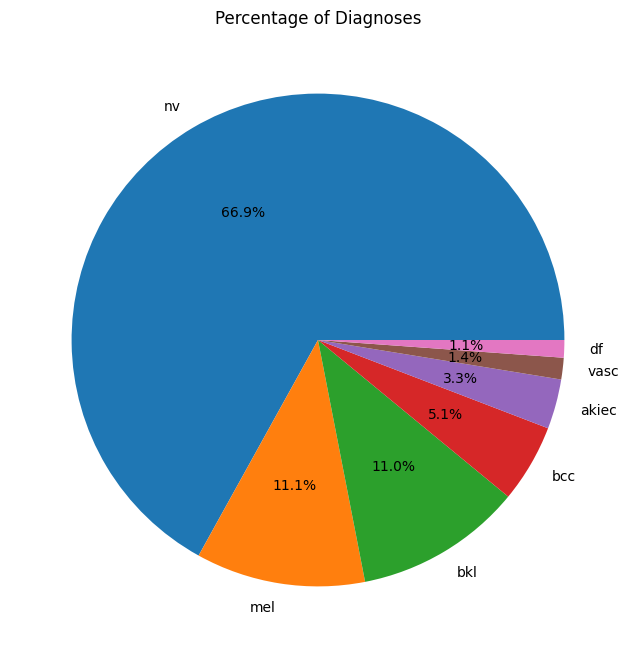

In [2]:
# Load the metadata CSV
tabular_data = pd.read_csv("D:/AIML/Dataset/archive2/HAM10000_metadata.csv")
print(tabular_data.head(10))

# Count the occurrences of each diagnosis
dx_counts = tabular_data['dx'].value_counts()

# Pie chart for diagnosis distribution
dx_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Percentage of Diagnoses')
plt.ylabel('')
plt.show()


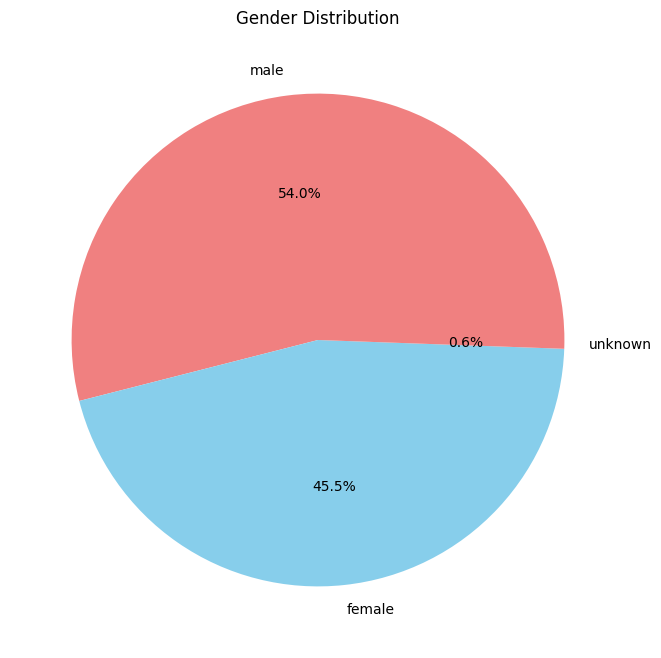

In [3]:
# Count occurrences of each sex
sex_counts = tabular_data['sex'].value_counts()

# Pie chart for gender distribution
sex_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'skyblue'], figsize=(8, 8))
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()


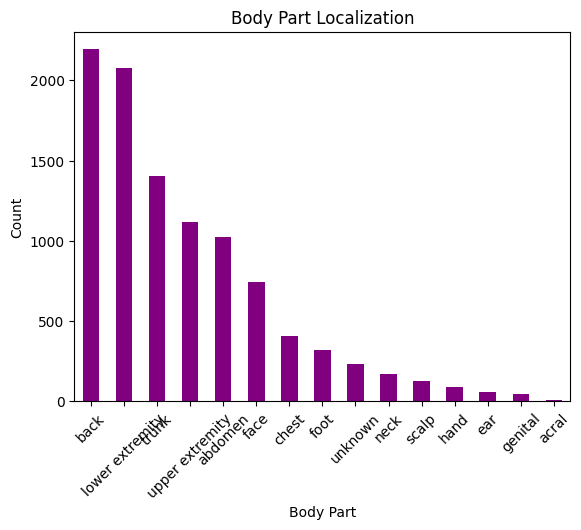

In [4]:
# Count occurrences of each localization
localization_counts = tabular_data['localization'].value_counts()

# Bar chart for body part localization distribution
localization_counts.plot(kind='bar', color='purple')
plt.title('Body Part Localization')
plt.xlabel('Body Part')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


C:\Users\KENNETH\AppData\Local\Temp\ipykernel_31004\425142507.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='dx', y='age', data=tabular_data, palette='pastel')


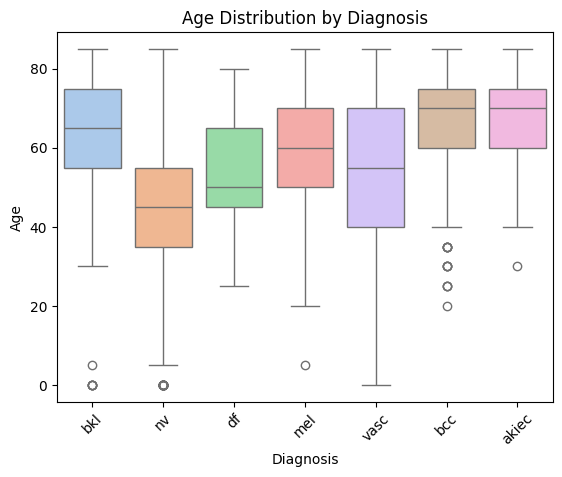

In [5]:
# Boxplot of Age Distribution by Diagnosis
sns.boxplot(x='dx', y='age', data=tabular_data, palette='pastel')
plt.title('Age Distribution by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.show()


In [6]:
# Load image data
data = pd.read_csv('D:/AIML/Dataset/archive2/hmnist_28_28_RGB.csv')
print(data.head(5))

# Separate features (pixels) and labels
X = data.drop(columns=['label']).values
y = data['label'].values

# Oversample the data using sklearn's resample
X_resampled, y_resampled = resample(X, y, replace=True, n_samples=len(X), random_state=42)

# Reshape the oversampled data
X_resampled = np.array(X_resampled).reshape(-1, 28, 28, 3)
print('Shape of X after oversampling:', X_resampled.shape)

# Standardizing the data
X = (X - np.mean(X)) / np.std(X)

# Splitting Data into Training and Testing Sets
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=1)
print(f'Training set size: {X_train.shape}, Testing set size: {X_test.shape}')


   pixel0000  pixel0001  pixel0002  pixel0003  pixel0004  pixel0005  \
0        192        153        193        195        155        192   
1         25         14         30         68         48         75   
2        192        138        153        200        145        163   
3         38         19         30         95         59         72   
4        158        113        139        194        144        174   

   pixel0006  pixel0007  pixel0008  pixel0009  ...  pixel2343  pixel2344  \
0        197        154        185        202  ...        173        124   
1        123         93        126        158  ...         60         39   
2        201        142        160        206  ...        167        129   
3        143        103        119        171  ...         44         26   
4        215        162        191        225  ...        209        166   

   pixel2345  pixel2346  pixel2347  pixel2348  pixel2349  pixel2350  \
0        138        183        147        166

In [8]:
# Check the shape of the input data
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# Ensure the shape is (num_samples, 28, 28, 3)


Training data shape: (8012, 2352)
Testing data shape: (2003, 2352)


In [9]:
# Reshape the data to have 28x28x3 dimensions
X_train = X_train.reshape(-1, 28, 28, 3)
X_test = X_test.reshape(-1, 28, 28, 3)

# Verify the new shapes
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (8012, 28, 28, 3)
Testing data shape: (2003, 28, 28, 3)


In [11]:
# Reset the TensorFlow session (clears any prior models or variables)
tf.keras.backend.clear_session()

# Rebuild and compile the model (just in case it was not initialized properly)
model = Sequential([
    Input(shape=(28, 28, 3)),
    Conv2D(16, kernel_size=(3, 3), activation='relu', padding='same'),
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2), padding='same'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(7, activation='softmax')
])

# Re-compile the model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [13]:
# Model checkpoint callback
callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',  # changed to `.keras` extension
    monitor='val_accuracy',       # monitoring validation accuracy
    mode='max',
    save_best_only=True,
    verbose=1
)


In [14]:
# Compile the model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [15]:
# Training the model
history = model.fit(
    X_train, Y_train,
    validation_split=0.2,
    batch_size=128,
    epochs=20,
    callbacks=[callback]
)


Epoch 1/20
49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6273 - loss: 1.1736
Epoch 1: val_accuracy improved from -inf to 0.67686, saving model to best_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6292 - loss: 1.1664 - val_accuracy: 0.6769 - val_loss: 0.9220
Epoch 2/20
49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6762 - loss: 0.8999
Epoch 2: val_accuracy improved from 0.67686 to 0.68996, saving model to best_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6764 - loss: 0.8990 - val_accuracy: 0.6900 - val_loss: 0.8509
Epoch 3/20
49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6957 - loss: 0.8484
Epoch 3: val_accuracy improved from 0.68996 to 0.71241, saving model to best_model.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6960 - loss: 0.8478 - val_accuracy: 0.7124 - val_loss: 0.8131
Epoch 4/20
49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7315 - loss: 0.7494
Epoch 4: val_accuracy did not improve from 0.712

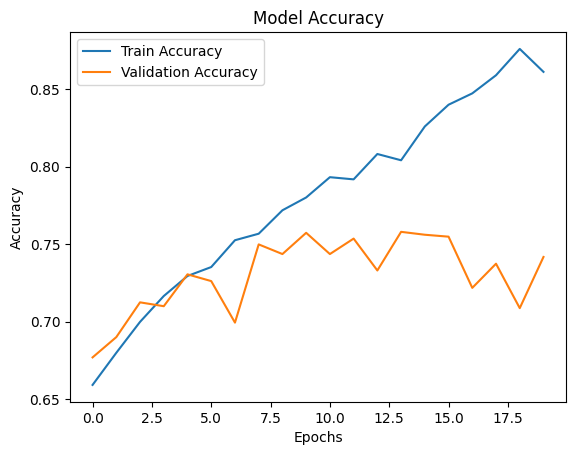

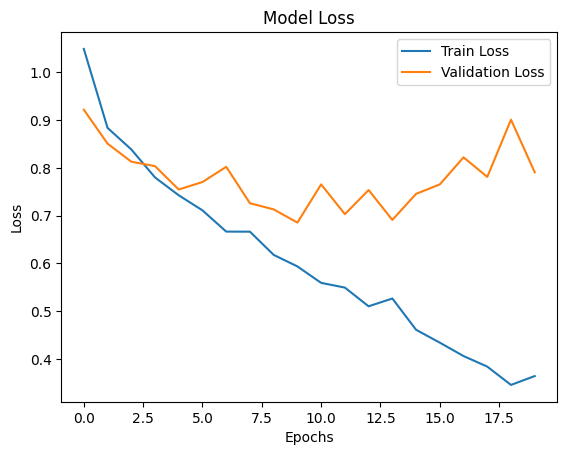

In [16]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')
plt.show()


In [17]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=1)

# Print test results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7522 - loss: 0.7824
Test Loss: 0.8100
Test Accuracy: 74.49%


In [18]:
# Predicting the classes for X_test
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)  # Convert probabilities to class indices

# Evaluate accuracy
accuracy = accuracy_score(Y_test, predicted_classes)
print(f'Accuracy on Test Set: {accuracy * 100:.2f}%')

# Classification report for detailed metrics
from sklearn.metrics import classification_report

# Define class names based on the dataset
class_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
print("\nClassification Report:")
print(classification_report(Y_test, predicted_classes, target_names=class_names))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy on Test Set: 74.49%

Classification Report:
              precision    recall  f1-score   support

          nv       0.36      0.44      0.39        61
         mel       0.51      0.47      0.49        96
         bkl       0.49      0.46      0.48       228
         bcc       0.00      0.00      0.00        37
       akiec       0.87      0.89      0.88      1327
        vasc       0.81      0.53      0.64        32
          df       0.46      0.50      0.48       222

    accuracy                           0.74      2003
   macro avg       0.50      0.47      0.48      2003
weighted avg       0.73      0.74      0.74      2003



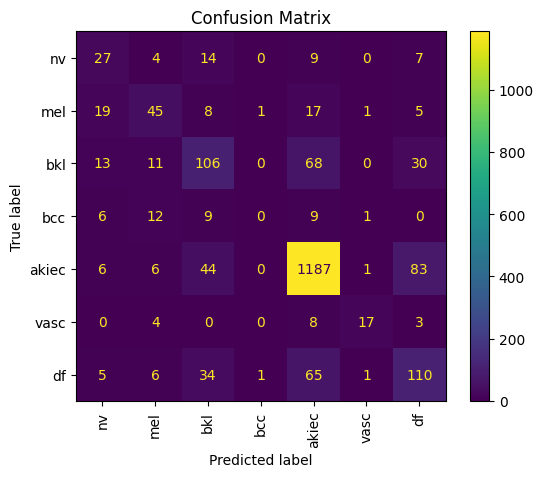

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
conf_matrix = confusion_matrix(Y_test, predicted_classes)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap='viridis', xticks_rotation='vertical')  # Rotate x-axis labels for better readability
plt.title("Confusion Matrix")
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0540416711637093..1.9096259176805706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.552207542985668..2.039582232068908].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2706355284776043..2.061241617800297].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.7254826288367844..1.9096259176805706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.137010957733185..1.4980975887841699].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3139542999403835..1.6063945174411176].
Clipping input data to the

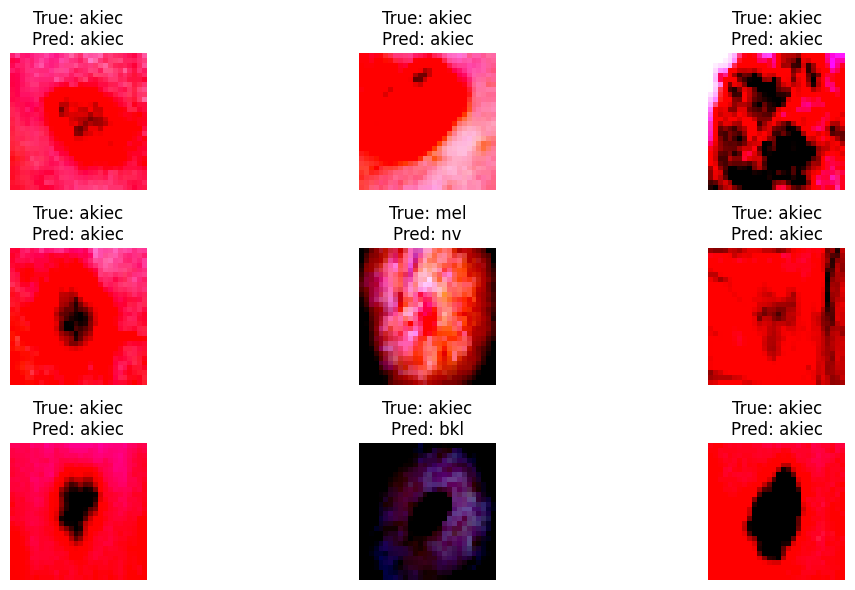

In [20]:
import matplotlib.pyplot as plt

# Visualize some test images with predictions
plt.figure(figsize=(12, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i])
    plt.title(f"True: {class_names[Y_test[i]]}\nPred: {class_names[predicted_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()
